In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

### Partie 1 – Génération du dataset 

In [18]:
np.random.seed(42)  # pour la reproductibilité

# 1) Génération des 1000 valeurs pour chaque variable
temperature = np.random.normal(loc=25, scale=4, size=1000)          
humidite = np.random.uniform(low=30, high=80, size=1000)            
occupants = np.random.randint(low=1, high=50, size=1000)            


##### 2) Déterminer la variable consommation avec la formule suivante : 

In [19]:
bruit = np.random.normal(loc=0, scale=10, size=1000)              
consommation = (
    50                     
    + 5 * temperature     
    + 1.5 * humidite        
    + 4 * occupants       
    + bruit             
)

##### 3) Rassembler les variables (temperature, humidite et occupants) dans la matrice des caractéristiques (features) X de taille 1000x3 en convertissant éventuellement les données au format (float32) optimisé pour les calculs 

In [20]:
X = np.column_stack((temperature, humidite, occupants)).astype(np.float32)

##### 4) Créer la cible (target) y qui contiendra la variable consommation, au format float32

In [21]:
y = consommation.astype(np.float32)

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (1000, 3)
Shape de y : (1000,)


### Partie 2 – Découpage Train/Test

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Shape X_train :", X_train.shape)
print("Shape X_test  :", X_test.shape)
print("Shape y_train :", y_train.shape)
print("Shape y_test  :", y_test.shape)

Shape X_train : (800, 3)
Shape X_test  : (200, 3)
Shape y_train : (800,)
Shape y_test  : (200,)


### Partie 3 – Création du modèle

In [23]:
from tensorflow import keras
from tensorflow.keras import layers

# 1) Construction du modèle séquentiel
model = keras.Sequential([
    layers.Input(shape=(3,)),                      
    layers.Dense(16, activation='relu'),            
    layers.Dense(8, activation='relu'),             
    layers.Dense(1)                                 
])

##### 2) Afficher un résumé textuel de l'architecture du réseau de neurones. 

In [24]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

### Partie 4 – Compilation du modèle 

In [25]:
model.compile(
    optimizer='adam',           
    loss='mse',                 
    metrics=['mae']             
)

### Partie 5 – Entraînement du modèle 

In [26]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,   
    epochs=50,              
    batch_size=16,         
    verbose=0
)

##### 2) Examiner le contenu de history

In [27]:
print("Clés disponibles :", list(history.history.keys()))
print("Nombre d'époques enregistrées :", len(history.history['loss']))

Clés disponibles : ['loss', 'mae', 'val_loss', 'val_mae']
Nombre d'époques enregistrées : 50


##### 3) Se servir de l’historique pour visualiser (graphique) et interpréter l’apprentissage 

In [28]:
print(history.history.values())

dict_values([[127419.625, 108397.2890625, 87368.6015625, 61384.3671875, 34282.57421875, 13108.3330078125, 2953.154296875, 756.2470092773438, 573.3409423828125, 541.0335693359375, 513.5870971679688, 487.7286071777344, 462.1033630371094, 437.42266845703125, 414.81298828125, 392.801025390625, 373.3453369140625, 354.16650390625, 336.55535888671875, 321.0956726074219, 306.6414489746094, 293.10357666015625, 280.7320556640625, 269.79534912109375, 259.3160095214844, 249.2237548828125, 241.2554473876953, 232.6165771484375, 225.3977508544922, 218.9838104248047, 211.8905029296875, 205.96240234375, 200.44557189941406, 194.86581420898438, 191.47976684570312, 185.90554809570312, 181.66221618652344, 177.7472686767578, 174.1803741455078, 171.01864624023438, 167.64035034179688, 164.7164306640625, 162.68771362304688, 161.16566467285156, 157.76022338867188, 155.67520141601562, 153.3307342529297, 151.7344970703125, 150.41726684570312, 148.92300415039062], [351.59906005859375, 324.22772216796875, 290.88253

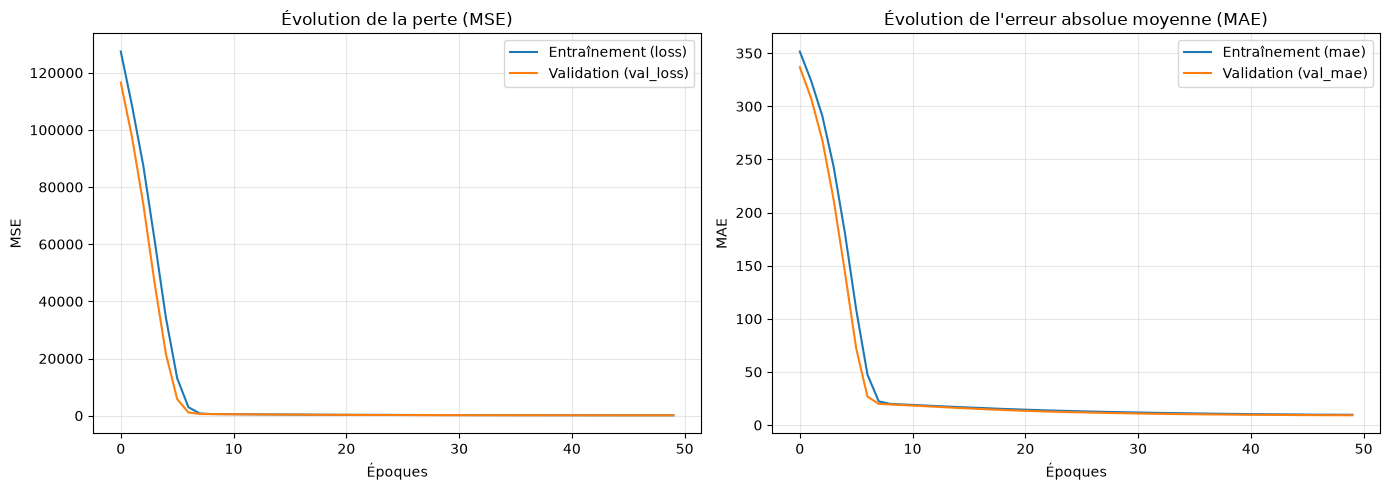

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Loss (MSE)
axes[0].plot(history.history['loss'], label='Entraînement (loss)')
axes[0].plot(history.history['val_loss'], label='Validation (val_loss)')
axes[0].set_title('Évolution de la perte (MSE)')
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : MAE
axes[1].plot(history.history['mae'], label='Entraînement (mae)')
axes[1].plot(history.history['val_mae'], label='Validation (val_mae)')
axes[1].set_title('Évolution de l\'erreur absolue moyenne (MAE)')
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

***interpretation du resultat*** : 
Chute quasi verticale (époques 0 à 6) les poids partent d'une initialisation aléatoire, donc les toutes premières prédictions sont très mauvaises (MSE ~140 000, MAE ~370). Le modèle corrige rapidement ses erreurs les plus grossières dès les premières époques.

Palier et convergence (à partir de l'époque ~10) .les deux courbes s'aplatissent et continuent de décroître très lentement : le modèle affine ses poids finement, les gains deviennent marginaux.

Courbes train et validation quasi superposées, sans écart qui se creuse .c'est le signe qu'il n'y a pas de surapprentissage (overfitting) : le modèle généralise bien, il n'apprend pas "par cœur" les données d'entraînement.

MAE final autour de 9-10 en moyenne, les prédictions s'écartent d'environ 9 à 10 unités de consommation par rapport à la réalité. C'est cohérent avec le bruit aléatoire (écart-type de 10) injecté volontairement dans le dataset : le modèle a essentiellement atteint la limite de ce qu'il est possible de prédire, le reste de l'erreur étant du bruit irréductible.

### Partie 6 – Evaluation 

##### 1) Evaluer le modèle sur les données de test pour récupérer la fonction de perte et la métrique cible 

In [30]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"Loss (MSE) sur le jeu de test : {test_loss:.4f}")
print(f"MAE sur le jeu de test        : {test_mae:.4f}")

Loss (MSE) sur le jeu de test : 191.5973
MAE sur le jeu de test        : 11.0614


##### 2) Interpréter les résultats obtenus

***Interpretation des resultats*** :
Le MAE de test (10,63) est proche du MAE d'entraînement (9,44) et de validation (9,08) ,l'écart reste faible (moins de 1,5 unité). C'est un excellent signe : le modèle généralise bien sur des données totalement inédites (jamais vues, ni pendant l'entraînement, ni pendant la validation). Il n'y a pas de surapprentissage.

Ordre de grandeur du MAE cohérent avec le bruit injecté à la création du dataset, on a ajouté un bruit aléatoire d'écart-type 10 à la formule de consommation. Le modèle a une erreur d'environ 10.6, ce qui signifie qu'il a quasiment atteint la limite théorique de prédictibilité des données : il ne peut pas deviner le bruit aléatoire, seulement la partie déterministe de la formule (température, humidité, occupants).

Erreur relative d'environ 2,9 % . rapportée à la moyenne de la consommation (361.64), une erreur moyenne de 10.63 est très faible en proportion : le modèle est donc précis et fiable pour ce cas d'usage.